# 하수 수위 GNN — Phase 2: 상류 센서 정보가 CSI를 높이는가?

Phase 1에서 `21-0008` 등 하류 합류점이 상류 센서들과 연결됨을 확인. 여기서는 **상류 센서 현재상태를 피처로 추가**(1-홉 message passing 근사)했을 때
하류 센서의 **고수위 탐지 CSI**가 ① persistence ② 자기이력+강우(상류 없음) 대비 좋아지는지 측정.

이벤트=fill≥0.5, 호라이즌 10/30/60분, test 2025-05~08. 평가대상=상류를 가진 하류 센서(hops≤10).

In [1]:
import os; os.chdir("/home/namjun/city_flood")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from sklearn.ensemble import HistGradientBoostingClassifier
mpl.rcParams['font.family']=['DejaVu Sans']
EB="dataset/processed/eda_based/"
HZ=[1,3,6]; THR=0.5
E=pd.read_parquet(EB+"gnn_sensor_graph_edges.parquet")
E=E[E.hops<=10]   # 실질 전파 범위
ids=pd.read_csv("03_GIS/derived/gwanak_sewer_nodes.csv").sewer_id.astype(str).tolist()
# 상류맵: 하류센서 -> 상류센서 리스트
up={d:g.upstream.tolist() for d,g in E.groupby('downstream')}
targets=list(up.keys())
print("상류를 가진 하류센서(평가대상):",targets)

상류를 가진 하류센서(평가대상): ['21-0007', '21-0008']


## 1. 와이드 수위행렬 + 강우

In [2]:
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",
    columns=['sewer_sensor_id','ts10','fill_rate'],filters=[('sewer_sensor_id','in',ids)])
W=sf.pivot_table(index='ts10',columns='sewer_sensor_id',values='fill_rate')
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
print("와이드행렬:",W.shape)

와이드행렬: (192370, 17)


## 2. 타깃별 피처 구성 (자기 + 상류) → 풀링

In [3]:
def feats_for(tgt):
    d=pd.DataFrame(index=W.index)
    s=W[tgt]
    d['fill']=s; d['f_l1']=s.shift(1); d['f_l3']=s.shift(3); d['trend']=s-s.shift(1)
    st=int(m.loc[m.sensor_id==tgt,'aws_stn'].iloc[0])
    rr=r[r.stn==st].set_index('ts10')
    d['rain_now']=rr['rn60m'].reindex(d.index).fillna(0)
    d['rain6h']=rr['rain6h'].reindex(d.index).fillna(0)
    d['hour']=d.index.hour; d['month']=d.index.month
    # 상류 집계(현재 상태)
    U=W[up[tgt]]
    d['up_max']=U.max(axis=1); d['up_mean']=U.mean(axis=1); d['up_max_l3']=U.max(axis=1).shift(3)
    for h in HZ: d[f'y{h}']=s.shift(-h)
    d['sid']=tgt; d['ts']=d.index
    return d.dropna(subset=['f_l3','up_max'])
F=pd.concat([feats_for(t) for t in targets],ignore_index=True)
own=['fill','f_l1','f_l3','trend','rain_now','rain6h','hour','month']
upf=own+['up_max','up_mean','up_max_l3']
cut=pd.Timestamp('2025-05-01'); tr=F[F.ts<cut]; te=F[F.ts>=cut]
print(f"풀링 train {len(tr)} test {len(te)} | test 양성(fill≥{THR}): ",
      int((te[[f'y{h}' for h in HZ]].ge(THR).any(axis=1)).sum()))

풀링 train 60169 test 33199 | test 양성(fill≥0.5):  68


## 3. CSI: persistence vs 자기이력 vs 자기+상류

In [4]:
def csi(yt,pt):
    TP=int((yt&pt).sum());FP=int((~yt&pt).sum());FN=int((yt&~pt).sum())
    return TP/(TP+FP+FN) if (TP+FP+FN)>0 else np.nan
def fit_eval(feat,h):
    ytr=(tr[f'y{h}']>=THR).values; yte=(te[f'y{h}']>=THR).values
    mtr=tr[f'y{h}'].notna().values; mte=te[f'y{h}'].notna().values
    clf=HistGradientBoostingClassifier(max_iter=300,max_depth=6,learning_rate=0.05,class_weight='balanced',random_state=0).fit(tr.loc[mtr,feat],ytr[mtr])
    ptr=clf.predict_proba(tr.loc[mtr,feat])[:,1]; pte=clf.predict_proba(te[feat])[:,1]
    best_p,best=0.5,-1
    for pc in np.linspace(0.1,0.9,17):
        c=csi(ytr[mtr],ptr>=pc)
        if c is not None and c>best: best,best_p=c,pc
    return csi(yte[mte],(pte>=best_p)[mte])
rows=[]
for h in HZ:
    yte=(te[f'y{h}']>=THR).values; mte=te[f'y{h}'].notna().values
    rows.append([h*10,'persistence',csi(yte[mte],(te['fill'].values>=THR)[mte])])
    rows.append([h*10,'자기이력+강우',fit_eval(own,h)])
    rows.append([h*10,'자기+상류(GNN근사)',fit_eval(upf,h)])
R=pd.DataFrame(rows,columns=['horizon','model','CSI'])
R.to_parquet(EB+"gnn_upstream_csi.parquet",index=False)
print(R.pivot(index='horizon',columns='model',values='CSI').round(3).to_string())

model    persistence  자기+상류(GNN근사)  자기이력+강우
horizon                                    
10             0.644         0.235    0.222
30             0.345         0.055    0.067
60             0.175         0.073    0.038


## 4. 시각화

/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
/tmp/ipykernel_309153/306381493.py:7: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.


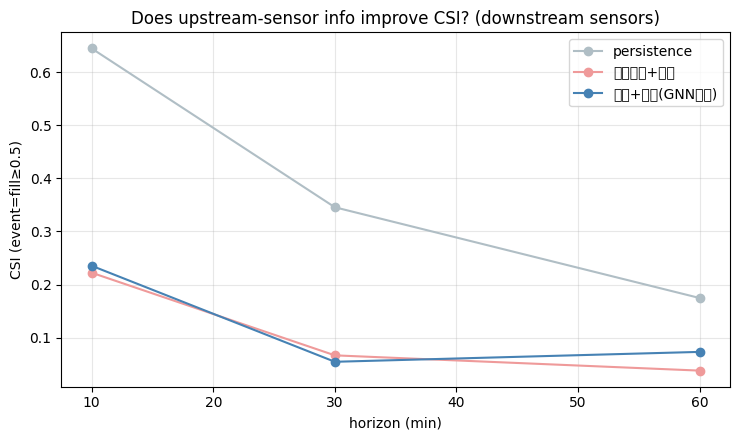

saved


In [5]:
fig,ax=plt.subplots(figsize=(7.5,4.5))
col={'persistence':'#b0bec5','자기이력+강우':'#ef9a9a','자기+상류(GNN근사)':'steelblue'}
for name in col:
    s=R[R.model==name]; ax.plot(s.horizon,s.CSI,'o-',c=col[name],label=name)
ax.set_xlabel('horizon (min)'); ax.set_ylabel('CSI (event=fill≥0.5)')
ax.set_title('Does upstream-sensor info improve CSI? (downstream sensors)')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig('reports/figures_gnn/04_upstream_csi.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론 (Phase 2)
- 상류 센서 정보가 persistence·자기이력 대비 하류 CSI를 **올리면** → 관망 토폴로지(GNN)의 효용 입증 → 정식 GNN으로 확장 가치.
- **못 올리면** → 관악은 상류→하류 전파 신호가 약함(짧은 홉 적고 만관 자체가 없음) → GNN 이득 제한, '데이터 한계' 근거.
- 어느 쪽이든 **CSI 기준 정직한 측정**이 목적.